# INITIAL COMMIT

Imports

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    confusion_matrix, classification_report,
)

import time
import seaborn as sns
import joblib

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


Reading the data

In [130]:
df = pd.read_csv("data/UNSW_NB15_training-set.csv")

### Feature engineering:

#### Dropping certain features
- "id" is an index and does not help with categorization
- "attack_cat" is an extension of a label and should not be included in the training data
- "stcpb" and "dtcpb" source and destination TCP base sequence number is randomly initialized and does not help with categorization

In [131]:
df.drop(["id", "attack_cat", "stcpb", "dtcpb"], axis=1, inplace=True)

#### One Hot Encoding columns with non-numerical data:
1. "proto" - the column denoting the protocol of the packet
2. "state" - state of the packet
3. "service" - 

In [132]:
# create map of groups to protocol
protocol_groups = {
    'common_transport': ['tcp', 'udp', 'sctp'],
    'routing': ['ospf', 'eigrp', 'egp', 'igp', 'nsfnet-igp', 'dgp', 'idrp', 'idpr', 'idpr-cmtp', 'sdrp', 'mhrp'],
    'tunneling': ['gre', 'ipip', 'l2tp', 'encap', 'etherip', 'mobile', 'ipcomp', 'ipnip', 'ip', 'micp'],
    'ipv6_family': ['ipv6', 'ipv6-frag', 'ipv6-route', 'ipv6-no', 'ipv6-opts'],
    'multicast': ['igmp', 'pim', 'vrrp', 'pgm', 'cbt'],
    'link_layer': ['arp', 'ax.25', 'fc', 'srp', 'il', 'ipx-n-ip'],
    'security': ['skip', 'tlsp', 'rsvp', 'kryptolan', 'secure-vmtp', 'aes-sp3-d', 'swipe', 'pri-enc'],
    'legacy': ['ggp', 'st2', 'argus', 'chaos', 'nvp', 'pup', 'xnet', 'mux', 'dcn', 'hmp', 'prm', 'trunk-1', 'trunk-2', 'xns-idp', 'leaf-1', 'leaf-2', 'irtp', 'rdp', 'netblt', 'mfe-nsp', 'merit-inp', '3pc', 'ddp', 'tp++', 'narp', 'any', 'cftp', 'sat-expak', 'ippc', 'sat-mon', 'cpnx', 'wsn', 'pvp', 'br-sat-mon', 'sun-nd', 'wb-mon', 'vmtp', 'ttp', 'vines', 'tcf', 'sprite-rpc', 'larp', 'mtp', 'bbn-rcc', 'bna', 'visa', 'ipcv', 'cphb', 'iso-tp4', 'wb-expak', 'sep', 'xtp', 'unas', 'iso-ip', 'aris', 'a/n', 'snp', 'compaq-peer', 'zero', 'ddx', 'iatp', 'stp', 'uti', 'sm', 'smp', 'isis', 'ptp', 'fire', 'crtp', 'crudp', 'sccopmce', 'iplt', 'pipe', 'sps', 'ib', 'emcon', 'gmtp', 'ifmp', 'pnni', 'qnx', 'scps']
}

# create a mapping of protocols to group
proto_to_group = {proto: group for group, protos in protocol_groups.items() for proto in protos}

# map protocol to their respective group
df['proto_group'] = df['proto'].map(proto_to_group).fillna('legacy')


In [133]:
# one hot encode protocol group
df_ohe = pd.get_dummies(df, columns=['proto_group', 'state', 'service'])

# convert boolean columns to int
bool_cols = df_ohe.select_dtypes(include='bool').columns
df_ohe[bool_cols] = df_ohe[bool_cols].astype(int)
df_ohe.drop(columns=["proto"], inplace=True)

#### Training/validation/test split

We split before normalizing so that we are able to calculate the averages of only the training set, and apply the transformations to the test and validation sets to prevent information leakage
- `stratify` used to ensure that the training/validation/test datasets will have an equal proportion of class labels as the original dataset. This is especially important for anormaly detection where there is a heavy class imbalance

In [134]:
# Remove labels before processing data
y = df_ohe.pop("label").values.astype(np.float32)
X = df_ohe

In [135]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 65865 | Val: 8233 | Test: 8234


#### Normalizing numerical columns

Inspecting the data
- Commented out describe to reduce file size

In [136]:
# Display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# df_numeric = df_ohe.select_dtypes(include=[np.number])
# df_numeric.describe(include='all')

Different columns need to be handled differently based on what information they represent and the skewedness of their data.
- `Log + StandardScalar` - for columns that are heavily skewed to the right
- `MixMaxScalar` - for columns that we know the hard boundaries for
- `Clip + Log + StandardScalar` - for columns that have extreme values that are deemed to be noise and contribute in no meaningful way to training
- `StandardScalar` - for columns that already have a roughly normal distribution

In [137]:
log_scale_cols = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'rate', 'dttl', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'smean', 'dmean', 'ct_flw_http_mthd', 'trans_depth', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']

std_scale_cols = ['tcprtt', 'synack', 'ackdat']

minmax_cols = ['sttl', 'swin', 'dwin']

# Columns needing clip before log
clip_cols = {
    'sloss': 0.99,
    'dloss': 0.99,
    'response_body_len': 0.99
}

# Apply clipping before the pipeline
for col, quantile in clip_cols.items():
    cap = X_train[col].quantile(quantile)  # fit on train only
    X_train[col] = X_train[col].clip(upper=cap)
    X_val[col]   = X_val[col].clip(upper=cap)
    X_test[col]  = X_test[col].clip(upper=cap)

# Add clipped columns to log group
log_scale_cols += list(clip_cols.keys())

# Add binary flag for response_body_len before dropping into pipeline
df_ohe['has_response_body'] = (df_ohe['response_body_len'] > 0).astype(np.float32)

# Build pipeline for Log + StandardScalar
log_transformer = Pipeline([
    ('log1p',  FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('log_scale',   log_transformer,  log_scale_cols),
    ('std_scale',   StandardScaler(), std_scale_cols),
    ('minmax',      MinMaxScaler(),   minmax_cols)
], remainder='passthrough')

# Fit on train only, transform all splits
X_train = preprocessor.fit_transform(X_train).astype(np.float32)
X_val = preprocessor.transform(X_val).astype(np.float32)
X_test = preprocessor.transform(X_test).astype(np.float32)

In [138]:
INPUT_DIM = X_train.shape[1]
print(f"Input dimension after preprocessing: {INPUT_DIM}")

Input dimension after preprocessing: 65


### Dataset and DataLoader

Dataset Class

In [139]:
class PacketsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

DataLoaders

In [140]:
train_dataset = PacketsDataset(X_train, y_train)
val_dataset = PacketsDataset(X_val,   y_val)
test_dataset = PacketsDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Model 

In [141]:
class NetworkAnomalyDetector(nn.Module):
    """
    Fully-connected binary classifier for network anomaly detection.

    Architecture:
        Input  -> Linear(256) -> BN -> ReLU -> Dropout
               -> Linear(128) -> BN -> ReLU -> Dropout
               -> Linear(64)  -> BN -> ReLU -> Dropout
               -> Linear(32)  -> BN -> ReLU -> Dropout
               -> Linear(1)   -> Sigmoid

    Args:
        input_dim (int):   Number of features after preprocessing.
        dropout_p (float): Dropout probability for each hidden block.
    """

    def __init__(self, input_dim: int, dropout_p: float = 0.3):
        super().__init__()

        self.network = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Block 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Block 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Block 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Output
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

        self._init_weights()

    def _init_weights(self):
        # He uniform initialisation for all Linear layers.
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


model = NetworkAnomalyDetector(input_dim=INPUT_DIM, dropout_p=0.3).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

NetworkAnomalyDetector(
  (network): Sequential(
    (0): Linear(in_features=65, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
    (17): Sigmoid()
  )
)

Trainable parameters: 61,121


#### Loss, Optimizer, Scheduler
- **Loss**: Weighted BCE — up-weights the minority malicious class by `n_benign / n_malicious` to counteract class imbalance.
- **Optimiser**: Adam with L2 weight decay.
- **Scheduler**: `ReduceLROnPlateau` halves the LR when val loss stagnates.

In [142]:
# # Positive class weight to handle imbalance
# n_neg = (y_train == 0).sum()
# n_pos = (y_train == 1).sum()
# pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
# print(f"pos_weight: {pos_weight.item():.2f}  (benign={n_neg:,}, malicious={n_pos:,})")


# def weighted_bce(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
#     """BCE loss with up-weighting of the positive (malicious) class."""
#     weights = torch.where(target == 1, pos_weight, torch.ones_like(target))
#     return (nn.functional.binary_cross_entropy(pred, target, reduction='none') * weights).mean()


# LR           = 1e-3
# WEIGHT_DECAY = 1e-4
# NUM_EPOCHS   = 50
# PATIENCE     = 7       # early stopping patience
# SAVE_PATH    = 'best_model.pth'

# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3
# )

In [143]:
# Positive class weight to handle imbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

# Compute raw ratio
raw_ratio = n_neg / n_pos

# Ensure we NEVER down-weight malicious samples
pos_weight_value = max(1.0, raw_ratio)

# Optional: slight bias towards detecting attacks (recommended for cybersecurity)
# pos_weight_value = max(1.5, raw_ratio)

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

print(f"pos_weight: {pos_weight.item():.2f}  (benign={n_neg:,}, malicious={n_pos:,})")


def weighted_bce(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """BCE loss with up-weighting of the positive (malicious) class."""
    weights = torch.where(target == 1, pos_weight, torch.ones_like(target))
    return (nn.functional.binary_cross_entropy(pred, target, reduction='none') * weights).mean()


# Hyperparameters
LR           = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS   = 50
PATIENCE     = 7       # early stopping patience
SAVE_PATH    = 'best_model.pth'

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler (reduce LR when validation loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

pos_weight: 1.00  (benign=29,600, malicious=36,265)


#### Training Loop

In [144]:
def run_epoch(loader: DataLoader, training: bool) -> dict:
    """
    One forward (and optionally backward) pass over *loader*.
    Returns a dict with loss, f1, roc_auc, probs, labels.
    """
    model.train() if training else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            loss  = weighted_bce(preds, y_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(X_batch)
            all_probs.append(preds.cpu().detach().numpy())
            all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs).flatten()
    all_labels = np.concatenate(all_labels).flatten()
    all_preds  = (all_probs >= 0.5).astype(int)

    return {
        'loss':    total_loss / len(loader.dataset),
        'f1':      f1_score(all_labels, all_preds, zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs),
        'probs':   all_probs,
        'labels':  all_labels,
    }

In [145]:
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_roc_auc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_stats = run_epoch(train_loader, training=True)
    val_stats   = run_epoch(val_loader,   training=False)

    scheduler.step(val_stats['loss'])

    history['train_loss'].append(train_stats['loss'])
    history['val_loss'].append(val_stats['loss'])
    history['val_f1'].append(val_stats['f1'])
    history['val_roc_auc'].append(val_stats['roc_auc'])

    print(
        f"Epoch [{epoch:03d}/{NUM_EPOCHS}]  "
        f"Train Loss: {train_stats['loss']:.4f}  |  "
        f"Val Loss: {val_stats['loss']:.4f}  |  "
        f"Val F1: {val_stats['f1']:.4f}  |  "
        f"Val AUC: {val_stats['roc_auc']:.4f}  |  "
        f"{time.time()-t0:.1f}s"
    )

    # Save best model
    if val_stats['loss'] < best_val_loss:
        best_val_loss    = val_stats['loss']
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✓  Best model saved to '{SAVE_PATH}'")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

# Reload best weights
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
print("\nTraining complete. Best weights reloaded.")

Epoch [001/50]  Train Loss: 0.2258  |  Val Loss: 0.1112  |  Val F1: 0.9585  |  Val AUC: 0.9923  |  6.0s
  ✓  Best model saved to 'best_model.pth'
Epoch [002/50]  Train Loss: 0.1449  |  Val Loss: 0.1078  |  Val F1: 0.9652  |  Val AUC: 0.9931  |  6.1s
  ✓  Best model saved to 'best_model.pth'
Epoch [003/50]  Train Loss: 0.1309  |  Val Loss: 0.1003  |  Val F1: 0.9621  |  Val AUC: 0.9937  |  5.7s
  ✓  Best model saved to 'best_model.pth'
Epoch [004/50]  Train Loss: 0.1253  |  Val Loss: 0.0988  |  Val F1: 0.9634  |  Val AUC: 0.9939  |  5.7s
  ✓  Best model saved to 'best_model.pth'
Epoch [005/50]  Train Loss: 0.1201  |  Val Loss: 0.1032  |  Val F1: 0.9629  |  Val AUC: 0.9928  |  5.4s
Epoch [006/50]  Train Loss: 0.1193  |  Val Loss: 0.0961  |  Val F1: 0.9665  |  Val AUC: 0.9947  |  5.6s
  ✓  Best model saved to 'best_model.pth'
Epoch [007/50]  Train Loss: 0.1168  |  Val Loss: 0.0955  |  Val F1: 0.9651  |  Val AUC: 0.9943  |  5.3s
  ✓  Best model saved to 'best_model.pth'
Epoch [008/50]  Trai

#### Training Curves

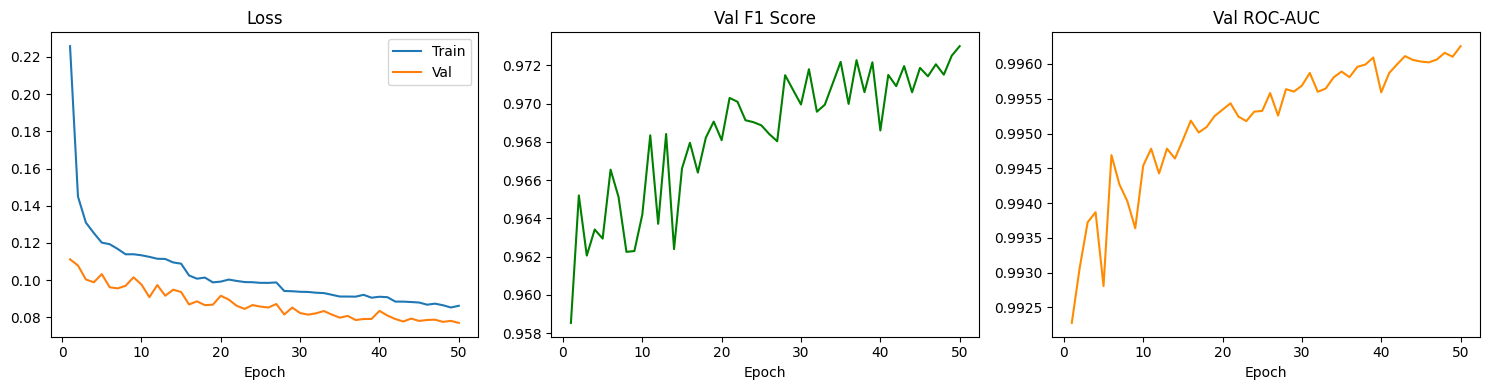

In [146]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['val_f1'], color='green')
axes[1].set_title('Val F1 Score')
axes[1].set_xlabel('Epoch')

axes[2].plot(epochs, history['val_roc_auc'], color='darkorange')
axes[2].set_title('Val ROC-AUC')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

#### Test Set Evaluation

In [147]:
test_stats = run_epoch(test_loader, training=False)
preds_bin  = (test_stats['probs'] >= 0.5).astype(int)

print('=== Test Set Results ===')
print(f"Loss      : {test_stats['loss']:.4f}")
print(f"Accuracy  : {accuracy_score(test_stats['labels'], preds_bin):.4f}")
print(f"Precision : {precision_score(test_stats['labels'], preds_bin, zero_division=0):.4f}")
print(f"Recall    : {recall_score(test_stats['labels'], preds_bin, zero_division=0):.4f}")
print(f"F1        : {test_stats['f1']:.4f}")
print(f"ROC-AUC   : {test_stats['roc_auc']:.4f}")
print()
print(classification_report(
    test_stats['labels'], preds_bin,
    target_names=['benign', 'malicious'], zero_division=0
))

=== Test Set Results ===
Loss      : 0.0885
Accuracy  : 0.9649
Precision : 0.9797
Recall    : 0.9561
F1        : 0.9677
ROC-AUC   : 0.9949

              precision    recall  f1-score   support

      benign       0.95      0.98      0.96      3700
   malicious       0.98      0.96      0.97      4534

    accuracy                           0.96      8234
   macro avg       0.96      0.97      0.96      8234
weighted avg       0.97      0.96      0.96      8234



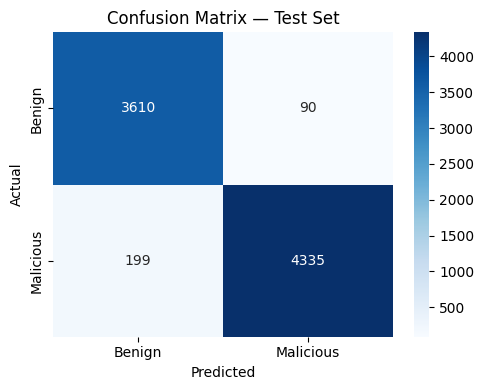

In [148]:
cm = confusion_matrix(test_stats['labels'], preds_bin)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malicious'],
            yticklabels=['Benign', 'Malicious'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

#### Save preprocessing artifects

In [149]:
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved to preprocessor.pkl")

# Save the column order that ColumnTransformer was fitted on
with open('feature_columns.json', 'w') as f:
    json.dump(list(df_ohe.columns), f)
print(f"Feature columns ({INPUT_DIM} total) saved to feature_columns.json")

Preprocessor saved to preprocessor.pkl


NameError: name 'json' is not defined